In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from typing import List, Dict, Literal

from model_ranking import (
    load_h5,
    find_selftraining_pred_paths,
    get_NA_prediction_path,
    get_ckpt_eval_scores,
    MODEL_ABBREVIATIONS_TO_DATASET,
)

INFO: P [MainThread] 2026-02-18 16:04:13,105 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
approach_mapping = {
    "def": "default_selftraining",
}

In [12]:
models: Dict[str, List[str]] = {
    "OvtoFw": [
        "OvtoFw_def_ov_model_NA1",
        "OvtoFw_def_ov_model_UNet1",
        "OvtoFw_def_ov_model_Res1",
    ],
    "PtoFw": [
        "PtoFw_def_p_model_NA1",
        "PtoFw_def_p_model_UNet1",
        "PtoFw_def_p_model_Res1",
    ]

}

In [13]:
base_transfer_path = Path("/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells")
direct_run_approach: Literal["consistency"] = "consistency"
direct_run_id = "P_fullslice"
eval_key = "MAP_05_095"
epochs = list(range(0, 6, 1))

Transfer: OvtoFw


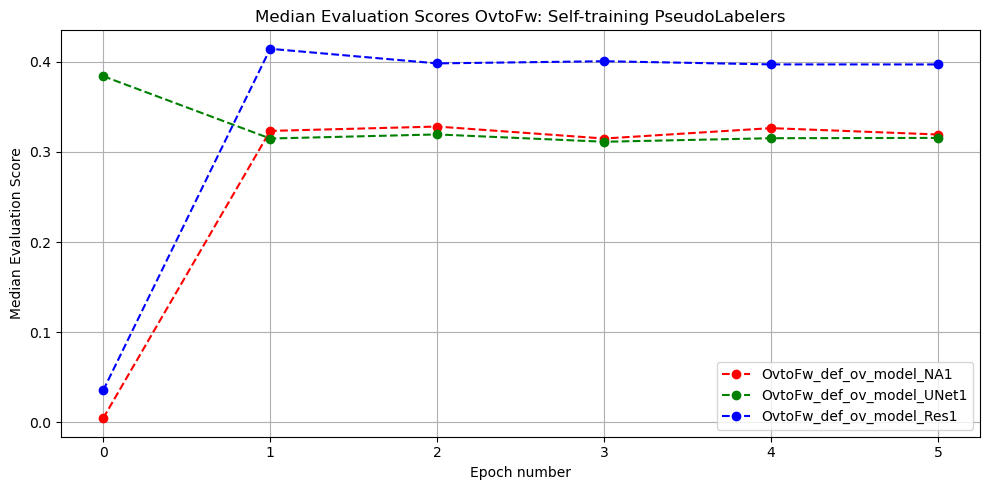

Transfer: PtoFw


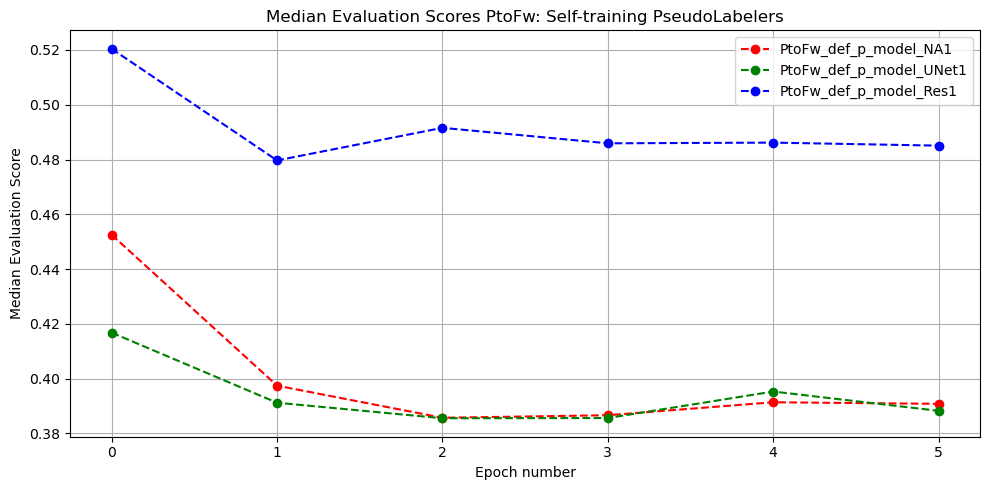

In [14]:
colours = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown', 'pink', 'gray']
base_path = Path("/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Cells")
best_epoch_per_transfer: Dict[str, Dict[str, int]] = {}
for transfer, model_list in models.items():
    print(f"Transfer: {transfer}")
    _ = plt.figure(figsize=(10,5))
    best_epochs_per_model: Dict[str, int] = {}
    for i, model_name in enumerate(model_list):

        approach = None
        #label = "_".join(model_name.split("_")[-2:])
        for key in approach_mapping:
            if key in model_name:
                approach = approach_mapping[key]

        assert approach is not None, f"Approach not found for model: {model_name}"
        #assert label is not None, f"Label not found for model: {model_name}"

        pred_path = find_selftraining_pred_paths([model_name], approach=approach, base_path=base_path)[0]

        epoch_ids = list(range(1, 6, 1))

        mean_eval_scores, median_eval_scores = get_ckpt_eval_scores(pred_path, epoch_ids, eval_key)

        initial_model_name = model_name.split("_def_")[1]
        target = MODEL_ABBREVIATIONS_TO_DATASET[transfer.split("to")[-1]]
        initial_pred_path = get_NA_prediction_path(
            model_name=initial_model_name,
            target=target,
            base_path=base_transfer_path,
            approach=direct_run_approach,
            run_id=direct_run_id,
        )
        eval_score_direct = load_h5(initial_pred_path, eval_key)
        median_eval_score_direct = np.median(eval_score_direct, axis=0)

        best_epoch_id = median_eval_scores.index(max(median_eval_scores))
        best_epochs_per_model[model_name] = best_epoch_id

        median_eval_scores.insert(0, median_eval_score_direct)
        
        _ = plt.plot(epochs, median_eval_scores, marker='o', linestyle='--', color=colours[i], label=model_name)


    best_epoch_per_transfer[transfer] = best_epochs_per_model

    _ =plt.title(f'Median Evaluation Scores {transfer}: Self-training PseudoLabelers')
    _ =plt.xlabel('Epoch number')
    _ =plt.ylabel(f'Median Evaluation Score')
    _ = plt.xticks(epochs)
    _ = plt.legend()
    plt.grid()
    plt.tight_layout()
        #plt.savefig("mean_eval_scores_over_checkpoints.png")
    plt.show()
